<a href="https://colab.research.google.com/github/Elsacred02/Progetto_AML_2025_2026/blob/main/Codice_progetto_AML_MobileNet_2025_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import tensorflow as tf

from google.colab import drive
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

In [2]:
# Monta dataset da google drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/sea_animals"

Mounted at /content/drive


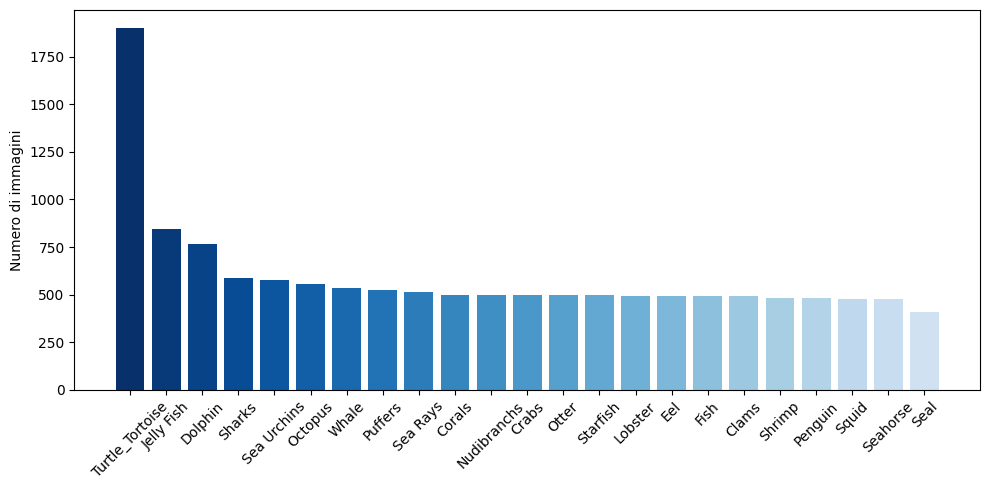

In [3]:
# Controllo bilanciamento dataset

dict_targets_NElements = {}

for directory in os.listdir(DATA_DIR):
    dict_targets_NElements[directory] = len(os.listdir(os.path.join(DATA_DIR, directory)))

dict_targets_NElements = dict(sorted(dict_targets_NElements.items(), key=lambda x: x[1], reverse=True))

colors = plt.cm.Blues(np.linspace(1, 0.2, len(dict_targets_NElements)))

plt.figure(figsize=(10, 5))
plt.bar(dict_targets_NElements.keys(), dict_targets_NElements.values(), color=colors)
plt.xticks(rotation=45)
plt.ylabel("Numero di immagini")
plt.tight_layout()
plt.show()

In [4]:
# Class weights (dataset sbilanciato)

num_classes = len(dict_targets_NElements)
print(f"Numero di classi: {num_classes}")

all_labels = []
class_names_ordered = sorted(dict_targets_NElements.keys())

for idx, class_name in enumerate(class_names_ordered):
    num_samples = dict_targets_NElements[class_name]
    all_labels.extend([idx] * num_samples)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_classes),
    y=all_labels
)

class_weights = dict(enumerate(class_weights_array))

print("\nClass Weights calcolati:")
for class_idx, class_name in enumerate(class_names_ordered):
    print(f"  {class_name}: {class_weights[class_idx]:.4f}")


Numero di classi: 23

Class Weights calcolati:
  Clams: 1.2017
  Corals: 1.1849
  Crabs: 1.1873
  Dolphin: 0.7699
  Eel: 1.1969
  Fish: 1.1969
  Jelly Fish: 0.7005
  Lobster: 1.1945
  Nudibranchs: 1.1849
  Octopus: 1.0596
  Otter: 1.1873
  Penguin: 1.2292
  Puffers: 1.1241
  Sea Rays: 1.1526
  Sea Urchins: 1.0265
  Seahorse: 1.2395
  Seal: 1.4386
  Sharks: 1.0107
  Shrimp: 1.2267
  Squid: 1.2369
  Starfish: 1.1897
  Turtle_Tortoise: 0.3112
  Whale: 1.1072


In [5]:
IMG_SIZE = 224
BATCH_SIZE = 64

# Suddivisione dataset (train/val/test)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_test_batches = tf.data.experimental.cardinality(val_test_ds)
val_ds = val_test_ds.take(val_test_batches // 2)
test_ds = val_test_ds.skip(val_test_batches // 2)

class_names = train_ds.class_names
print("Class names (ordine Keras):", class_names)


Found 13599 files belonging to 23 classes.
Using 10880 files for training.
Found 13599 files belonging to 23 classes.
Using 2719 files for validation.
Class names (ordine Keras): ['Clams', 'Corals', 'Crabs', 'Dolphin', 'Eel', 'Fish', 'Jelly Fish', 'Lobster', 'Nudibranchs', 'Octopus', 'Otter', 'Penguin', 'Puffers', 'Sea Rays', 'Sea Urchins', 'Seahorse', 'Seal', 'Sharks', 'Shrimp', 'Squid', 'Starfish', 'Turtle_Tortoise', 'Whale']


In [6]:
# Preprocessing specifico per MobileNetV2
train_ds_MN = train_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
val_ds_MN   = val_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
test_ds_MN  = test_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)

# Ottimizzazione pipeline
train_ds_MN = train_ds_MN.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds_MN   = val_ds_MN.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds_MN  = test_ds_MN.cache().prefetch(buffer_size=tf.data.AUTOTUNE)


# Inseriamo la data augmentation dentro il modello
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
], name='data_augmentation')

In [7]:
# Carica backbone pre-addestrato su ImageNet
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Congela i pesi del backbone per fase 1
base_model.trainable = False

# Costruisci il modello completo
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)  # Augmentation su GPU
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)  # Dropout leggero



outputs = layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs, name="MobileNetV2_MarineAnimals")
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_MarineAnimals"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │        29,463 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,287,447 (8.73 MB)

 Trainable params: 29,463 (115.09 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

earlystop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1,
    min_lr=1e-7
)

callbacks_phase1 = [earlystop, reduce_lr]

history_1 = model.fit(
    train_ds_MN,
    validation_data=val_ds_MN,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks_phase1
)

Epoch 1/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 2198s 13s/step - accuracy: 0.3577 - loss: 2.3270 - val_accuracy: 0.7545 - val_loss: 0.8425 - learning_rate: 0.0010
Epoch 2/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 21s 122ms/step - accuracy: 0.6653 - loss: 1.1962 - val_accuracy: 0.7932 - val_loss: 0.7349 - learning_rate: 0.0010
Epoch 3/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 19s 110ms/step - accuracy: 0.6944 - loss: 1.0785 - val_accuracy: 0.7932 - val_loss: 0.7089 - learning_rate: 0.0010
Epoch 4/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 18s 108ms/step - accuracy: 0.7117 - loss: 1.0160 - val_accuracy: 0.8021 - val_loss: 0.6830 - learning_rate: 0.0010
Epoch 5/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 19s 109ms/step - accuracy: 0.7249 - loss: 0.9775 - val_accuracy: 0.8103 - val_loss: 0.6687 - learning_rate: 0.0010
Epoch 6/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 19s 111ms/step - accuracy: 0.7292 - loss: 0.9546 - val_accuracy: 0.8080 - val_loss: 0.6647 - learning_rate: 0.0010
Epoch 7/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 19s 110ms/step - accuracy: 0.7

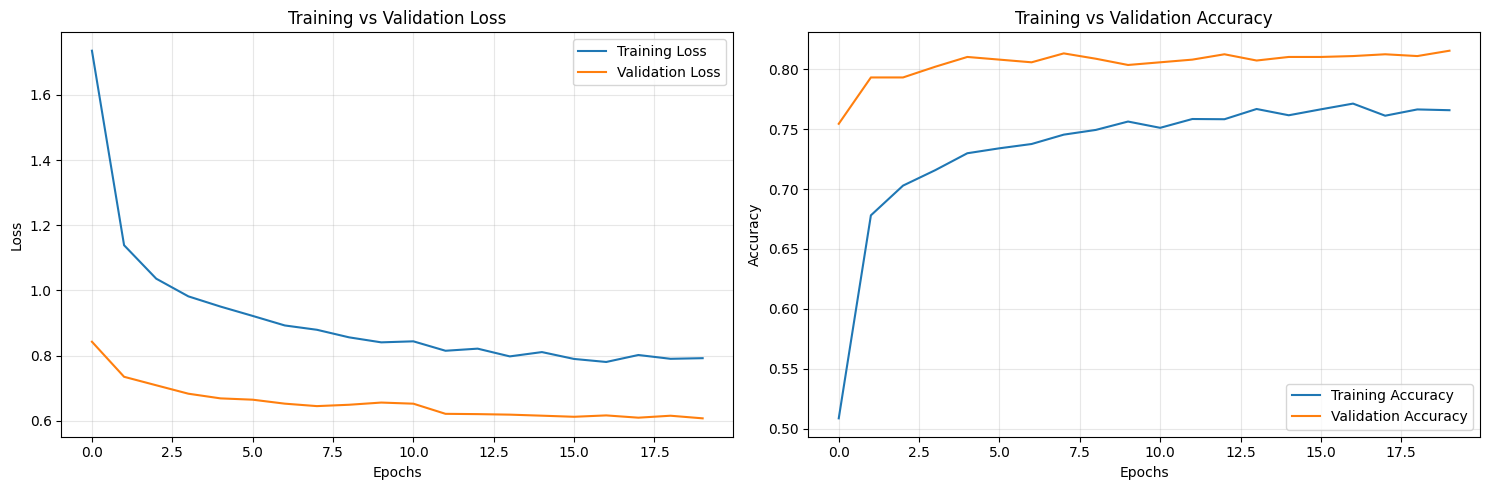

In [9]:
# Stampo in un grafico l'evoluzione dell'accuratezza in training e validazione

history_dict = history_1.history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history_dict['loss'], label='Training Loss')
ax1.plot(history_dict['val_loss'], label='Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_dict['accuracy'], label='Training Accuracy')
ax2.plot(history_dict['val_accuracy'], label='Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Validation Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Scongelo la prima porzione della rete
base_model.trainable = True

# Congelo tutti i layer tranne gli ultimi 20
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.summary()

Model: "MobileNetV2_MarineAnimals"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │        29,463 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,346,375 (8.95 MB)

 Trainable params: 1,235,543 (4.71 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

 Optimizer params: 58,928 (230.19 KB)

In [12]:
# Ricompila con learning rate più basso
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [earlystop, reduce_lr]

# Training fase 2
history_2 = model.fit(
    train_ds_MN,
    validation_data=val_ds_MN,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks_phase2
)

Epoch 1/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 36s 142ms/step - accuracy: 0.6719 - loss: 1.2545 - val_accuracy: 0.8118 - val_loss: 0.6230 - learning_rate: 1.0000e-05
Epoch 2/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 23s 134ms/step - accuracy: 0.7076 - loss: 1.0355 - val_accuracy: 0.8080 - val_loss: 0.6338 - learning_rate: 1.0000e-05
Epoch 3/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 22s 131ms/step - accuracy: 0.7330 - loss: 0.9259 - val_accuracy: 0.8118 - val_loss: 0.6270 - learning_rate: 1.0000e-05
Epoch 4/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 22s 132ms/step - accuracy: 0.7344 - loss: 0.9098 - val_accuracy: 0.8199 - val_loss: 0.6147 - learning_rate: 1.0000e-05
Epoch 5/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 23s 133ms/step - accuracy: 0.7496 - loss: 0.8600 - val_accuracy: 0.8162 - val_loss: 0.6090 - learning_rate: 1.0000e-05
Epoch 6/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 22s 132ms/step - accuracy: 0.7488 - loss: 0.8379 - val_accuracy: 0.8192 - val_loss: 0.6035 - learning_rate: 1.0000e-05
Epoch 7/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 23s 13

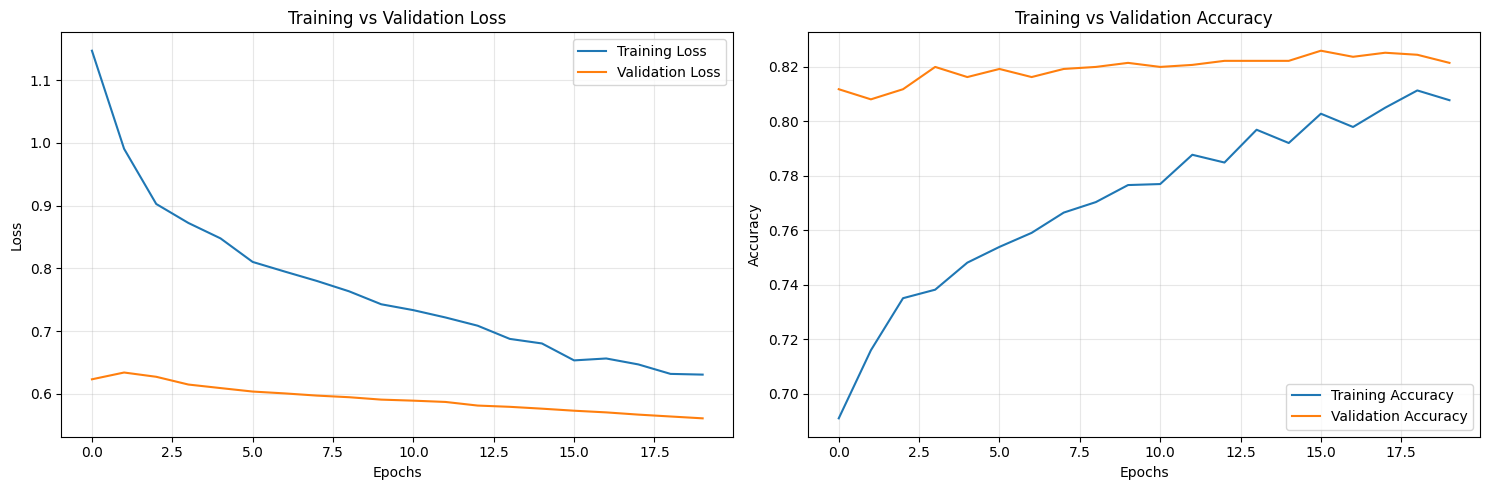

In [13]:
history_dict = history_2.history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history_dict['loss'], label='Training Loss')
ax1.plot(history_dict['val_loss'], label='Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_dict['accuracy'], label='Training Accuracy')
ax2.plot(history_dict['val_accuracy'], label='Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Validation Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Valutazione del modello sul Test Set
print("--- Valutazione sul Test Set ---")
test_loss, test_accuracy = model.evaluate(test_ds_MN, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}\n")

# Generazione predizioni
print("--- Generazione Predizioni ---")

# Estrazione coerente di y_true e y_pred
y_true = []
y_pred = []

for x_batch, y_batch in test_ds_MN:
    preds = model.predict(x_batch, verbose=0)
    y_pred.append(np.argmax(preds, axis=1))
    y_true.append(y_batch.numpy())

y_true = np.concatenate(y_true, axis=0)
y_pred = np.concatenate(y_pred, axis=0)

print("\n--- Classification Report ---")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=3
))


--- Valutazione sul Test Set ---
22/22 ━━━━━━━━━━━━━━━━━━━━ 258s 10s/step - accuracy: 0.8077 - loss: 0.6290

Test Loss: 0.6373
Test Accuracy: 0.8065

--- Generazione Predizioni ---

--- Classification Report ---
                 precision    recall  f1-score   support

          Clams      0.605     0.605     0.605        38
         Corals      0.600     0.661     0.629        59
          Crabs      0.950     0.974     0.962        39
        Dolphin      0.824     0.872     0.847        86
            Eel      0.633     0.756     0.689        41
           Fish      0.569     0.688     0.623        48
     Jelly Fish      0.963     0.987     0.975        79
        Lobster      0.726     0.763     0.744        59
    Nudibranchs      0.782     0.860     0.819        50
        Octopus      0.755     0.588     0.661        68
          Otter      0.979     1.000     0.989        47
        Penguin      0.833     0.784     0.808        51
        Puffers      0.761     0.844     0.800

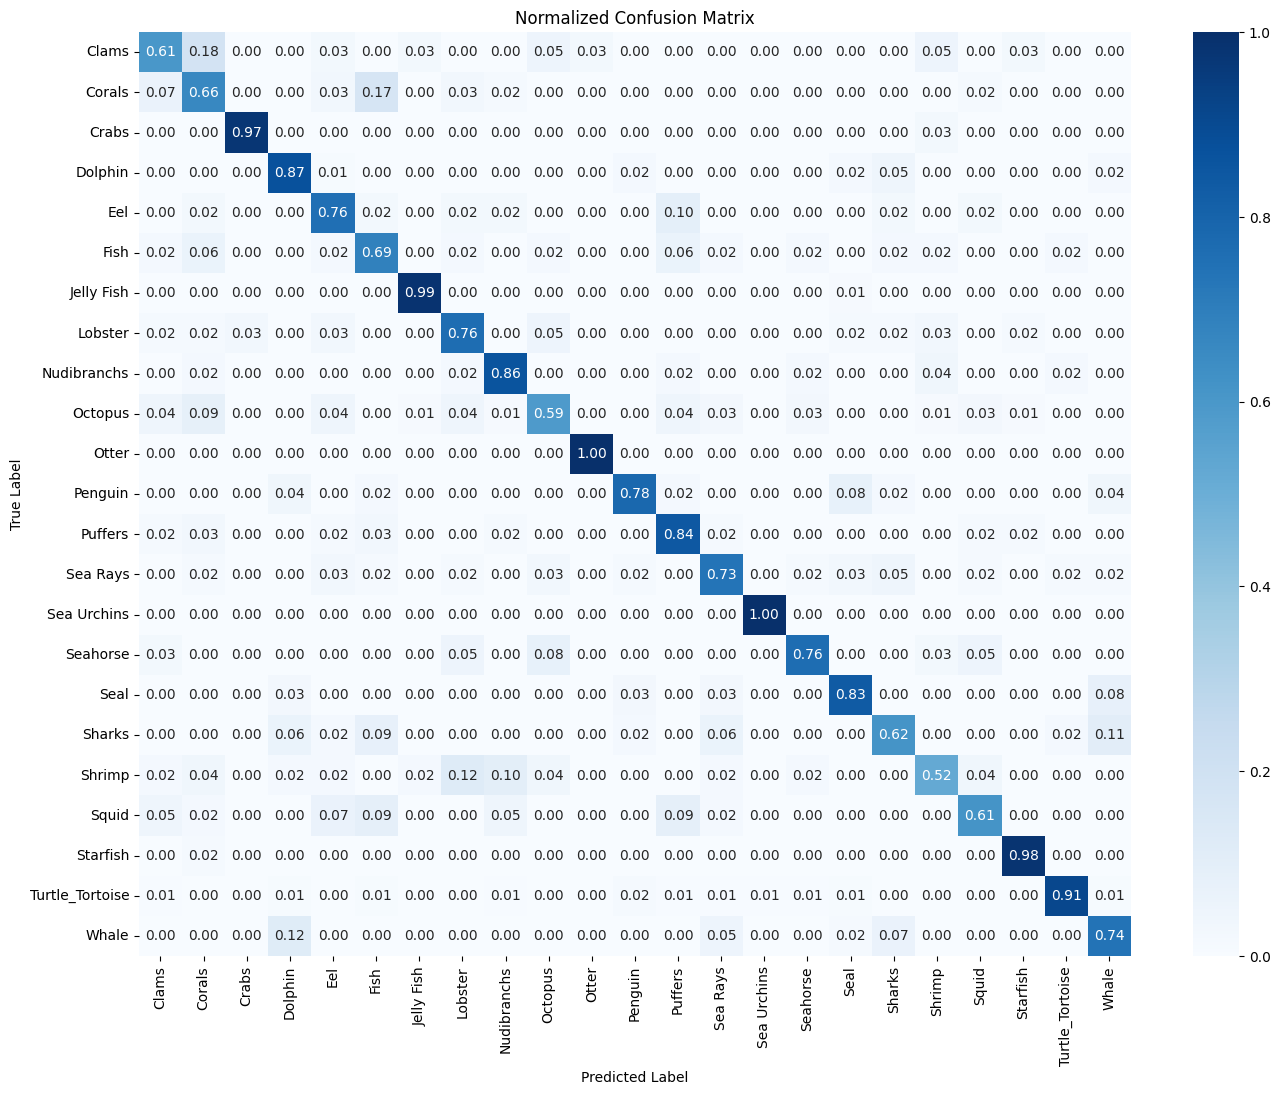

In [15]:
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(16, 12))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.show()